In [158]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from ultralytics import YOLO
import torch

In [159]:
import sys
PROJECT_ROOT = r"D:\FYP\PlantGrowth"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
sys.path.insert(0, PROJECT_ROOT)

In [160]:
#Zhang–Suen

def zhang_suen_thinning(image):

    img = image.copy() // 255
    changing1 = changing2 = True

    while changing1 or changing2:

        changing1 = []
        rows, cols = img.shape

        for x in range(1, rows - 1):
            for y in range(1, cols - 1):

                P2 = img[x-1, y]
                P3 = img[x-1, y+1]
                P4 = img[x, y+1]
                P5 = img[x+1, y+1]
                P6 = img[x+1, y]
                P7 = img[x+1, y-1]
                P8 = img[x, y-1]
                P9 = img[x-1, y-1]

                if img[x, y] == 1:

                    neighbors = [P2,P3,P4,P5,P6,P7,P8,P9]
                    C = sum((neighbors[i] == 0 and neighbors[(i+1)%8] == 1)
                            for i in range(8))
                    N = sum(neighbors)

                    if (2 <= N <= 6 and
                        C == 1 and
                        P2 * P4 * P6 == 0 and
                        P4 * P6 * P8 == 0):

                        changing1.append((x,y))

        for x,y in changing1:
            img[x,y] = 0

        changing2 = []

        for x in range(1, rows - 1):
            for y in range(1, cols - 1):

                P2 = img[x-1, y]
                P3 = img[x-1, y+1]
                P4 = img[x, y+1]
                P5 = img[x+1, y+1]
                P6 = img[x+1, y]
                P7 = img[x+1, y-1]
                P8 = img[x, y-1]
                P9 = img[x-1, y-1]

                if img[x, y] == 1:

                    neighbors = [P2,P3,P4,P5,P6,P7,P8,P9]
                    C = sum((neighbors[i] == 0 and neighbors[(i+1)%8] == 1)
                            for i in range(8))
                    N = sum(neighbors)

                    if (2 <= N <= 6 and
                        C == 1 and
                        P2 * P4 * P8 == 0 and
                        P2 * P6 * P8 == 0):

                        changing2.append((x,y))

        for x,y in changing2:
            img[x,y] = 0

    return (img * 255).astype(np.uint8)


In [169]:
class VegetationGrowthModel:

    def segment(self, image):

        img = image.astype(np.float32) / 255.0
        B, G, R = cv2.split(img)

        exg = 2 * G - R - B
        exg = (exg - exg.min()) / (exg.max() - exg.min() + 1e-6)
        exg_mask = (exg > 0.2).astype(np.uint8) * 255

        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        lower = np.array([35, 40, 40])
        upper = np.array([85, 255, 255])
        hsv_mask = cv2.inRange(hsv, lower, upper)

        mask = cv2.bitwise_and(exg_mask, hsv_mask)

        kernel = np.ones((5,5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

        if num_labels > 1:
            largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
            clean_mask = np.zeros_like(mask)
            clean_mask[labels == largest_label] = 255
        else:
            clean_mask = mask

        return clean_mask


    def extract_features(self, mask):

        leaf_area = np.sum(mask > 0)
        area_ratio = leaf_area / mask.size

        contours, _ = cv2.findContours(mask,
                                       cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)

        leaf_count = sum(1 for c in contours if cv2.contourArea(c) > 300)

        binary = (mask > 0).astype(np.uint8)
        skeleton = skeletonize(binary).astype(np.uint8)
        # skeleton = zhang_suen_thinning(mask)
        endpoints = 0
        for y in range(1, skeleton.shape[0]-1):
            for x in range(1, skeleton.shape[1]-1):
                if skeleton[y,x]:
                    neighbors = np.sum(skeleton[y-1:y+2, x-1:x+2]) - 1
                    if neighbors == 1:
                        endpoints += 1

        branch_complexity = endpoints

        return area_ratio, leaf_count, branch_complexity, skeleton


    def compute_growth(self, area_ratio, leaf_count, branch_complexity):

        count_score = min(leaf_count / 40, 1.0)
        branch_score = min(branch_complexity / 120, 1.0)

        vegetation_index = (
            0.45 * area_ratio +
            0.30 * count_score +
            0.25 * branch_score
        )

        growth_percent = vegetation_index * 58

        return min(58, max(0, growth_percent))


In [170]:
class HybridGrowthSystem:

    def __init__(self, yolo_path=None):

        self.vegetation_model = VegetationGrowthModel()

        if yolo_path:
            self.detector = YOLO(yolo_path)
        else:
            self.detector = None


    def detect_fruit(self, image):

        if self.detector is None:
            return False, None

        results = self.detector(image, verbose=False)[0]

        if len(results.boxes) == 0:
            return False, None

        return True, results


    def predict(self, image):

        fruit_present, results = self.detect_fruit(image)

        mask = self.vegetation_model.segment(image)

        area_ratio, leaf_count, branch_complexity, skeleton = \
            self.vegetation_model.extract_features(mask)

        veg_growth = self.vegetation_model.compute_growth(
            area_ratio, leaf_count, branch_complexity
        )

        if not fruit_present:
            return {
                "mode": "vegetative",
                "growth": veg_growth,
                "mask": mask,
                "skeleton": skeleton,
                "detections": None
            }

        else:
            full_growth = 58 + (veg_growth / 58) * 42

            return {
                "mode": "fruiting",
                "growth": min(100, full_growth),
                "mask": mask,
                "skeleton": skeleton,
                "detections": results
            }


In [171]:
def visualize_vegetation(image, mask, skeleton, growth):

    skeleton = skeleton.astype(np.uint8)

    # ---- Strong thickening ----
    kernel = np.ones((9,9), np.uint8)  # much thicker
    thick_skeleton = cv2.dilate(skeleton, kernel, iterations=1)

    overlay = image.copy()

    # Color skeleton bright red
    overlay[thick_skeleton > 0] = [255, 0, 0]

    # ---- Endpoint Detection ----
    endpoints = []

    for y in range(1, skeleton.shape[0]-1):
        for x in range(1, skeleton.shape[1]-1):
            if skeleton[y,x]:
                neighbors = np.sum(skeleton[y-1:y+2, x-1:x+2]) - 1
                if neighbors == 1:
                    endpoints.append((x,y))

    # Draw endpoints as large blue circles
    for (x,y) in endpoints:
        cv2.circle(overlay, (x,y), 12, (0,0,255), -1)

    # print("Leaf Count:", np.sum(mask > 0))
    print("Skeleton Endpoints:", len(endpoints))
    
    fig, ax = plt.subplots(1,4, figsize=(24,6))

    ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Original")

    ax[1].imshow(mask, cmap="gray")
    ax[1].set_title("Leaf Mask")

    ax[2].imshow(thick_skeleton*255, cmap="gray")
    ax[2].set_title("Thick Skeleton")

    ax[3].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    ax[3].set_title(f"Growth: {growth:.2f}%")
    
    for a in ax:
        a.axis("off")

    plt.tight_layout()
    plt.show()


In [172]:
def visualize_yolo(image, results, growth):

    annotated = results.plot()

    plt.figure(figsize=(8,8))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"Fruiting Stage | Growth: {growth:.2f}%")
    plt.axis("off")
    plt.show()


Mode: fruiting
Growth %: 76.98921254960317


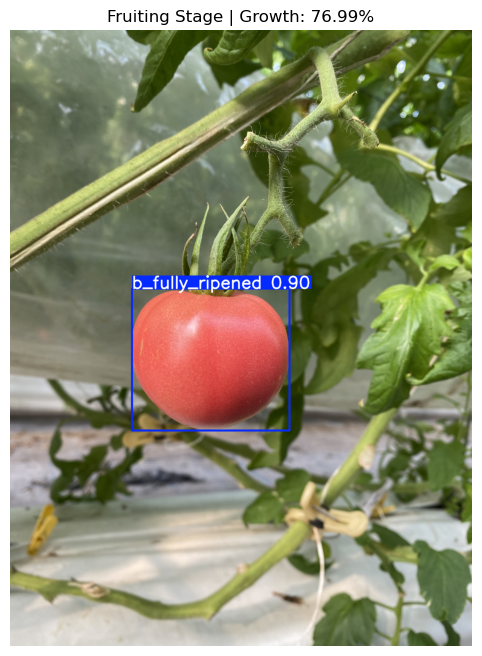

In [173]:
system = HybridGrowthSystem(yolo_path="../runs/detect/runs/laboro_fast_high_map50/weights/best.pt")

# img = cv2.imread(r"D:\FYP\PlantGrowth\data\stage_dataset\flowering\1710490230287.jpg")

img = cv2.imread(r"D:\FYP\PlantGrowth\data\laboro_tomato\train\images\IMG_0990.jpg")

output = system.predict(img)

print("Mode:", output["mode"])
print("Growth %:", output["growth"])

if output["mode"] == "vegetative":
    visualize_vegetation(img,
                         output["mask"],
                         output["skeleton"],
                         output["growth"])

else:
    visualize_yolo(img,
                   output["detections"],
                   output["growth"])


Mode: vegetative
Growth %: 17.704230450125973
Skeleton Endpoints: 125


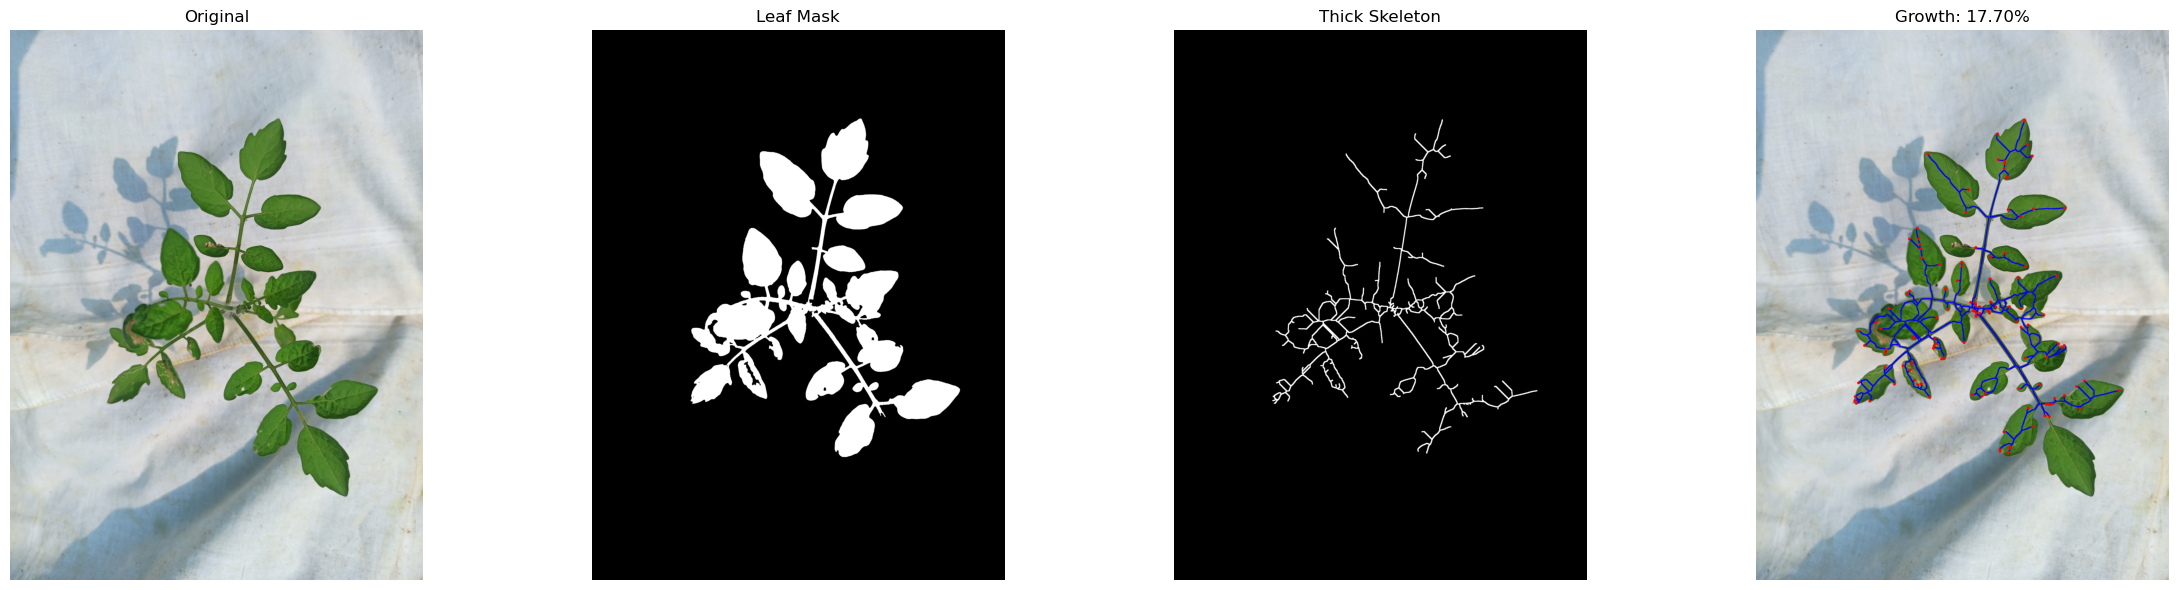

In [174]:
system = HybridGrowthSystem(yolo_path="../runs/detect/runs/laboro_fast_high_map50/weights/best.pt")

img = cv2.imread(r"D:\FYP\PlantGrowth\data\stage_dataset\flowering\1710490230287.jpg")

# img = cv2.imread(r"D:\FYP\PlantGrowth\data\laboro_tomato\train\images\IMG_0990.jpg")

output = system.predict(img)

print("Mode:", output["mode"])
print("Growth %:", output["growth"])

if output["mode"] == "vegetative":
    visualize_vegetation(img,
                         output["mask"],
                         output["skeleton"],
                         output["growth"])

else:
    visualize_yolo(img,
                   output["detections"],
                   output["growth"])


Mode: vegetative
Growth %: 6.497165406646063
Skeleton Endpoints: 24


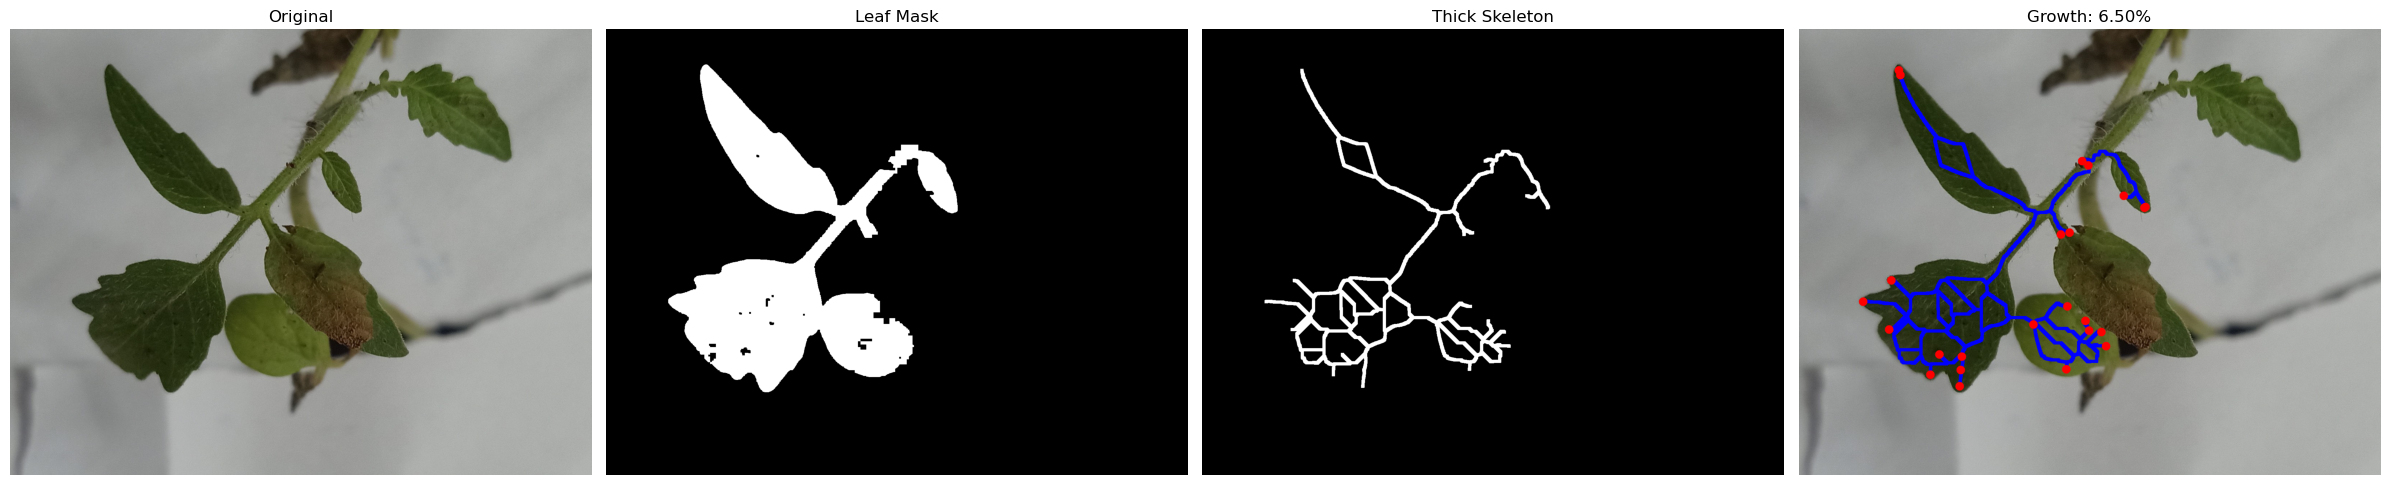

In [184]:
system = HybridGrowthSystem(yolo_path="../runs/detect/runs/laboro_fast_high_map50/weights/best.pt")

img = cv2.imread(r"D:\FYP\PlantGrowth\train\models\outside3.jpg")

# img = cv2.imread(r"D:\FYP\PlantGrowth\data\laboro_tomato\train\images\IMG_0990.jpg")

output = system.predict(img)

print("Mode:", output["mode"])
print("Growth %:", output["growth"])

if output["mode"] == "vegetative":
    visualize_vegetation(img,
                         output["mask"],
                         output["skeleton"],
                         output["growth"])

else:
    visualize_yolo(img,
                   output["detections"],
                   output["growth"])
